# Network ReAct Agent - Demo Notebook
"Reasoning Loop with External State"

## Setup

In [1]:
import sys
from pathlib import Path

# Add src to path so we can import the package
sys.path.insert(0, str(Path.cwd().parent / "src"))

import json

from langchain_core.messages import HumanMessage

from network_manager_agent import (
    LLMConfig,
    build_agent,
    create_llm,
)
from network_manager_agent.data import DataManager

## Load and Pre-compute Data: Filter & Aggregate (done by DataManager)

In [2]:
county_specialty_thresholds = {
    "mi": {
        "wayne": {"general practice": 10.0, "cardiology": 15.0},
        "washtenaw": {"general practice": 10.0, "cardiology": 15.0},
    }
}

dm = DataManager(county_specialty_thresholds=county_specialty_thresholds)
candidates = dm.get_candidates_df()
members = dm.get_members_df()

print(f"Loaded {len(candidates)} candidates, {len(members)} members")

Loaded 85615 candidates, 12051 members


## Create LLM

In [3]:
llm_config = LLMConfig(base_url="http://localhost:8080/v1")
llm = create_llm(llm_config)

# Quick test
response = llm.invoke("Hey there! Just making sure you're up and running!")

In [4]:
content = response.content.strip()
print(f"LLM response: {content}")

LLM response: Hey! Yes, I'm up and running smoothly. Thanks for checking in! 😊 What can I help you with today?


In [5]:
reasoning = response.additional_kwargs.get("reasoning_content", "No reasoning provided")
print(f"LLM reasoning: {reasoning}")

LLM reasoning: Here's a thinking process:

1.  **Analyze User Input:**
   - User says: "Hey there! Just making sure you're up and running!"
   - Tone: Friendly, casual, checking system status
   - Intent: Verify that I'm operational and responsive

2.  **Identify Key Requirements:**
   - Acknowledge the greeting
   - Confirm operational status
   - Match the friendly/casual tone
   - Keep it concise
   - Offer assistance

3.  **Formulate Response (Mental Refinement):**
   - "Hey! Yes, I'm up and running smoothly. Thanks for checking in! What can I help you with today?"
   - Check tone: Friendly, matches user's vibe
   - Check content: Confirms status, invites next question
   - Check length: Concise

4.  **Final Output Generation:** (Matches the refined version)
   - "Hey! Yes, I'm up and running smoothly. Thanks for checking in! 😊 What can I help you with today?" (Added a light emoji for tone match, but keep it professional)

   Actually, I'll keep it clean and professional but warm: 

## Build Agent

In [6]:
import sqlite3
from pathlib import Path

from langgraph.checkpoint.sqlite import SqliteSaver

db_path = str(Path.cwd().parent / "checkpoints.sqlite")
conn = sqlite3.connect(db_path, check_same_thread=False)
checkpointer = SqliteSaver(conn)
agent = build_agent(llm, checkpointer=checkpointer)
print("Agent built successfully!")


Agent built successfully!


## Visualize Graph

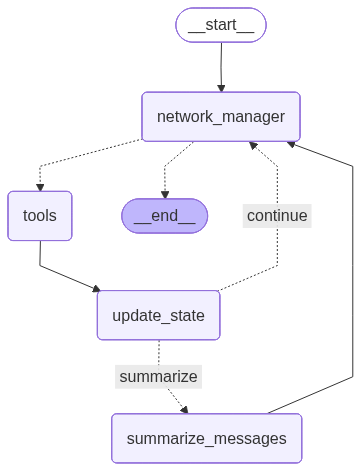

In [7]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


## Run the Agent

In [8]:
from network_manager_agent.ui import run_agent


def run_agent_demo(agent, inputs: dict, config: dict):
    """Wrapper for run_agent that matches the notebook's naming convention."""
    run_agent(agent, inputs, config)


In [9]:
# Create a thread
config = {"configurable": {"thread_id": "test_anchor_recommendation1"}}


In [10]:
# Specify an input
messages = [HumanMessage(content='''
I'm looking for a large health system to anchor my network. I know we only have a few specialties and counties in our network currently. 
But I want to see which health systems would provide good coverage to our current network plus have a breadth of specialties in case we need want to expand in the future. 
Can you provide a ranked list of the top 5 health systems that would be good candidates for us to pursue based on our current network and that have a good breadth of specialties?
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
    "sandbox_cache": {},
}

run_agent_demo(agent, inputs, config)


Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL: run_code ---
    # First, let's understand the current network and candidate data
    print("Current network entities:")
    print(network_df["entity"].unique())
    print(f"\nTotal contracted providers: {len(network_df)}")
    print(f"\nCandidate providers: {len(candidates_df)}")
    print(f"\nUnique candidate entities: {candidates_df['entity'].nunique()}")
    
    # Check the specialties in candidates
    print("\nSpecialties in candidates:")
    print(candidates_df["specialty"].value_counts().head(20))
    
    # Check counties in members
    print("\nMembers by county:")
    print(members_df["county"].value_counts())

>>>> NODE: tools <<<<
   --- TOOL RESULT (run_code) ---
    [stdout]
Current network entities:
<StringArray>
[]
Length: 0, dtype: str

Total contracted providers: 0

Candidate providers: 85615

Unique candidate entities: 8609

Specialties in candidates:
specialty
internal medicine        

In [11]:
# Specify an input
messages = [HumanMessage(content='''
Explain your methodology in detail. I want to understand how you arrived at your recommendations.
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- CURRENT CONTENT ---
================================== Ai Message ==================================

# Detailed Methodology Explanation

## **1. Data Foundation & Scope Definition**

### Network Baseline
- **Current Network**: 0 contracted providers (greenfield network)
- **Candidate Pool**: 85,615 providers across 8,609 unique entities
- **Member Population**: 12,051 total members
  - Wayne County: 10,257 members (85.1%)
  - Washtenaw County: 1,794 members (14.9%)

### Target Specialties & Thresholds
Based on your network configuration:
- **General Practice**: 10-mile service radius
- **Cardiology**: 15-mile service radius
- Counties: Wayne and Washtenaw (Michigan)

---

## **2. Candidate Entity Identification**

### Step 1: Entity Aggregation
I aggregated provider-level data to entity-level by grouping `candidates_df` by the `entity` column, calculating:
- Provider count per entity
- Unique specialty count
- Averag

## Inspect Agent State

In [ ]:
# Show the last human message from the conversation
state = agent.get_state(config)
messages = state.values.get("messages", [])
last_human = [m for m in reversed(messages) if m.type == 'human']
print("Last human message:")
print(last_human[0].content if last_human else "(none)")


In [ ]:
print("Summary:")
print(state.values.get("summary", "(empty)"))

print()

print("Schema profile:")
schema = state.values.get("schema_profile", "")
print(f"  {len(schema)} chars" if schema else "  (empty)")


In [ ]:
import pandas as pd
print("Current network (list of entity IDs):")
network = agent.get_state(config).values.get("network", [])
if network:
    for i, entity_id in enumerate(network, 1):
        print(f"  {i}. {entity_id}")
else:
    print("  (empty - no entities added yet)")


## Try a More Complex Prompt

In [ ]:
# Reset with a new thread
# config = {"configurable": {"thread_id": "2"}}

messages = [HumanMessage(content='''
Complex prompt here
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
}

# run_agent_demo(agent, inputs, config)


In [ ]:
# # Check final state
# state = agent.get_state(config)
# print("Summary:")
# print(state.values.get("summary", "(empty)"))

# print("\nNetwork (entity IDs):")
# network = state.values.get("network", [])
# if network:
#     for i, entity_id in enumerate(network, 1):
#         print(f"  {i}. {entity_id}")
# else:
#     print("  (empty)")
